In [1]:
import pybaseball as pyb
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import pandas as pd
from IPython.display import Image

pd.set_option('display.max_columns', 999)
pd.set_option("display.max_seq_items", None)

PLAYER_ID = 672282
PLAYER_NAME = "Reid Detmers"
DATASET_NAME = "Detmers, Reid"

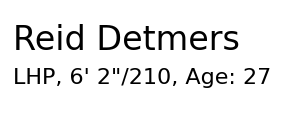

In [2]:
from PIL import Image
import requests
from io import BytesIO
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pybaseball import pitching_stats_bref, pitching_stats

# get all of this season's pitching data so far
data = pitching_stats_bref()
detmers_season_stats = data[data['Name'] == PLAYER_NAME]

def player_bio(pitcher_id: str, season_stats: pd.DataFrame):
    url = f"https://statsapi.mlb.com/api/v1/people?personIds={pitcher_id}&hydrate=currentTeam"
    data = requests.get(url).json()

    player_name = data['people'][0]['fullName']
    pitcher_hand = data['people'][0]['pitchHand']['code']
    age = data['people'][0]['currentAge']
    height = data['people'][0]['height']
    weight = data['people'][0]['weight']

    fig, ax = plt.subplots(figsize=(2, 1.25))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(0.02, 0.85, f'{player_name}', va='top', ha='left',
             fontsize=24, transform=ax.transAxes)
    ax.text(0.02, 0.40, f'{pitcher_hand}HP, {height}/{weight}, Age: {age}',
             va='top', ha='left', fontsize=16, transform=ax.transAxes)
    

    ax.axis('off')
    plt.show()

player_bio(PLAYER_ID, detmers_season_stats)

In [3]:
def plot_table(df: pd.DataFrame, title: str, figsize=None, color_col=None):
    n_rows, n_cols = df.shape
    if figsize is None:
        figsize = (max(6, n_cols * 1.8), max(2, n_rows * 0.35))

    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=8)

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='upper center',
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.6)

    color_col_idx = df.columns.get_loc(color_col) if color_col else None

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_text_props(fontweight='bold', color='white')
            cell.set_facecolor('#BA0021')
        elif col == color_col_idx:
            if color_col_idx is not None:
                pitch_code = df.iloc[row - 1, color_col_idx]
                cell.set_facecolor(dict_colour.get(pitch_code, '#f2f2f2' if row % 2 == 0 else 'white'))
        elif row % 2 == 0:
            cell.set_facecolor('#f2f2f2')

    fig.subplots_adjust(top=0.85, bottom=0.02)  # trims the leftover margin below the table
    plt.show()

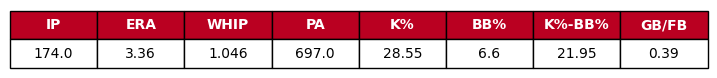

In [4]:
detmers_season_stats.rename(columns={'BF': 'PA'}, inplace=True)
detmers_season_stats['K%'] = ((detmers_season_stats['SO'] / detmers_season_stats['PA'])*100).round(2)
detmers_season_stats['BB%'] = ((detmers_season_stats['BB'] / detmers_season_stats['PA'])*100).round(2)
detmers_season_stats['K%-BB%'] = (detmers_season_stats['K%'] - detmers_season_stats['BB%']).round(2)
plot_table(detmers_season_stats[['IP', 'ERA', 'WHIP', 'PA', 'K%', 'BB%', 'K%-BB%', 'GB/FB']], title="", figsize=(9, 0.5))

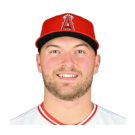

In [5]:
def player_headshot(pitcher_id: str):
    url = f'https://img.mlbstatic.com/mlb-photos/image/'\
          f'upload/d_people:generic:headshot:67:current.png'\
          f'/w_640,q_auto:best/v1/people/{pitcher_id}/headshot/silo/current.png'

    response = requests.get(url)
    img = Image.open(BytesIO(response.content))
    fig, ax = plt.subplots(figsize=(2, 1.5))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.imshow(img, extent=[0, 1, 0, 1], origin='upper')

    # Turn off the axis
    ax.axis('off')

player_headshot(pitcher_id=PLAYER_ID)

In [6]:
### PITCH COLOURS ### - Borrowing from TJStats
pitch_colours = {
    ## Fastballs ##
    'FF': {'colour': '#FF007D', 'name': '4-Seam Fastball'},
    'FA': {'colour': '#FF007D', 'name': 'Fastball'},
    'SI': {'colour': '#98165D', 'name': 'Sinker'},
    'FC': {'colour': '#BE5FA0', 'name': 'Cutter'},

    ## Offspeed ##
    'CH': {'colour': '#F79E70', 'name': 'Changeup'},
    'FS': {'colour': '#FE6100', 'name': 'Splitter'},
    'SC': {'colour': '#F08223', 'name': 'Screwball'},
    'FO': {'colour': '#FFB000', 'name': 'Forkball'},

    ## Sliders ##
    'SL': {'colour': '#67E18D', 'name': 'Slider'},
    'ST': {'colour': '#1BB999', 'name': 'Sweeper'},
    'SV': {'colour': '#376748', 'name': 'Slurve'},

    ## Curveballs ##
    'KC': {'colour': "#3F26B2", 'name': 'Knuckle Curve'},
    'CU': {'colour': '#3025CE', 'name': 'Curveball'},
    'CS': {'colour': '#274BFC', 'name': 'Slow Curve'},
    'EP': {'colour': '#648FFF', 'name': 'Eephus'},

    ## Others ##
    'KN': {'colour': '#867A08', 'name': 'Knuckleball'},
}

dict_colour = dict(zip(pitch_colours.keys(), [pitch_colours[key]['colour'] for key in pitch_colours]))

dict_pitch = dict(zip(pitch_colours.keys(), [pitch_colours[key]['name'] for key in pitch_colours]))


In [7]:
# Pulling Data from Statcast - commenting out since I only need to run once and read from the CSV

def loadSav(startdate, enddate):
    # format = 2020-09-28
    sav = pyb.statcast(start_dt=startdate, end_dt=enddate)
    print('{} Rows Imported'.format(str(len(sav))))
    return sav

sav = loadSav('2026-03-26', '2026-09-15')
sav.to_csv('../data2026.csv')

This is a large query, it may take a moment to complete


c:\Users\sethb\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
100%|██████████| 174/174 [00:16<00:00, 10.83it/s]


665297 Rows Imported


In [8]:
data = pd.read_csv('../data2026.csv')

In [70]:
FASTBALL = {'FF', 'SI', 'FC'}
BREAKING = {'SL', 'CU', 'KC', 'SV', 'ST'}
OFFSPEED = {'CH', 'FS'}

def pitch_to_family(pitch):
    if pd.isna(pitch):
        return None
    if pitch in FASTBALL:
        return 'fastball'
    if pitch in BREAKING:
        return 'breaking'
    if pitch in OFFSPEED:
        return 'offspeed'
    return None 

In [213]:
# Some initial processing of the raw Statcast data to help with my analysis
def sort_statcast(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(["game_date", "game_pk", "inning", "inning_topbot", "at_bat_number", "pitch_number"], ascending=[True, True, True, False, True, True]).reset_index(drop=True)

def df_processing(df_pyb: pd.DataFrame):
    df = df_pyb.copy()

    df = df[~df["pitch_type"].isin(['UN', 'PO'])]
    
    # Define codes for different types of swings and whiffs 
    swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip',
                  'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
    whiff_code = ['swinging_strike', 'bunt_foul_tip', 'foul_tip', 'swinging_strike_blocked']

    out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
                'double_play', 'fielders_choice_out', 'sac_fly']

    hit_code = ['hit_into_play']

    df['swing'] = (df['description'].isin(swing_code))
    df['whiff'] = (df['description'].isin(whiff_code))

    df['in_zone'] = (df['zone'] < 10)
    df['out_zone'] = (df['zone'] > 10)

    df['chase'] = (df.in_zone == False) & (df.swing == 1)

    df['out'] = (df['events'].isin(out_code))

    df['error'] = (df['events'].isin(['field_error']))

    df['strikeout'] = (df['events'].isin(['strikeout']))

    df['hit'] = (df.out == False) & (df.error == False) & (df['description'].isin(hit_code))

    df['ab_number'] = (
            df.groupby(['game_pk', 'inning', 'inning_topbot'])['at_bat_number']
            .rank(method='dense')
            .astype(int)
        )

    df['count'] = (df['balls'].astype(int).astype(str) + "-" + df['strikes'].astype(int).astype(str))

    df['pfx_x_in'] = df['pfx_x'] * 12
    df['pfx_z_in'] = df['pfx_z'] * 12

    df["pa_id"] = df["game_pk"].astype(str) + "_" + df["at_bat_number"].astype(str)
    abs_label = ["ABS"]
    is_abs = df["pitch_type"].isin(abs_label)
    df["pitch_type_for_next"] = df["pitch_type"].mask(is_abs)

    # Track last real pitch type within each PA, will be NaN until first pitch is actually thrown
    df["next_real_pitch_type"] = (df.groupby("pa_id")["pitch_type_for_next"].ffill())

    # Previous pitch type is the last real pitch but shifted 1. NaNs are now filled
    df["next_pitch_type"] = (df.groupby("pa_id")["next_real_pitch_type"].shift(-1).dropna())

    df["next_real_pitch_group"] = df["next_real_pitch_type"].map(pitch_to_family)
    df["next_pitch_group"] = (df.groupby("pa_id")["next_real_pitch_group"].shift(-1).dropna())

    # don't care about thse columns
    df = df.drop(columns=["pitch_type_for_next", "next_real_pitch_type", "next_real_pitch_group"])

    contact_map = {
        1.0: 'Weak',
        2.0: 'Topped', 
        3.0: 'Under',
        4.0: 'Flare/Burner',
        5.0: 'Solid Contact',
        6.0: 'Barrel'
    }

    df['launch_speed'] = df['launch_speed_angle'].map(contact_map)

    return df

data = data.copy()
data = sort_statcast(data)
data = df_processing(data)
league_fastball_data = data[data['pitch_type'] == 'FF']
league_curveball_data = data[data['pitch_type'] == 'CU']
league_slider_data = data[data['pitch_type'] == 'SL']

pitcher_data = data[data['pitcher'] == PLAYER_ID]

pitcher_fastball_data = pitcher_data[pitcher_data['pitch_type'] == 'FF']
pitcher_curveball_data = pitcher_data[pitcher_data['pitch_type'] == 'CU']
pitcher_slider_data = pitcher_data[pitcher_data['pitch_type'] == 'SL']


In [214]:
AVG_PLAYER_HEIGHT_FT = 6 + 1/12  

# function for plotting pitches on a strikezone. Can be used with any set of pitches, just pass in a dataframe with what to plot
def add_pitch_strike_zone(df: pd.DataFrame, ax: plt.Axes, title: str, column= "pitch_type"):
    plate_width_ft = 17 / 12

    z_bot = 0.27 * AVG_PLAYER_HEIGHT_FT
    z_top = 0.535 * AVG_PLAYER_HEIGHT_FT

    rect = Rectangle((-(plate_width_ft/2), z_bot),
                     plate_width_ft,                 # width
                     z_top - z_bot,                  # height
                     fill=False,
                     linewidth=2,
                     color='black', 
                     zorder=3)
    ax.add_patch(rect)

    pitch_counts = df[column].value_counts()
    total_pitches = len(df)

    artist_to_df = {}
    handles = []
    labels = []
    for pitch_type in pitch_counts.index:
        sub = df[df[column] == pitch_type].reset_index(drop=True)
        artist = ax.scatter(sub['plate_x'], sub['plate_z'],
                             color=dict_colour.get(pitch_type, '#9C8975'),
                             ec='black',
                             alpha=1,
                             zorder=2,
                             linewidths=0.5,
                             )
        artist_to_df[artist] = sub
        handles.append(artist)
        labels.append(f"{pitch_type}: {(pitch_counts[pitch_type] / total_pitches) * 100:.1f}%")
        
    ax.legend(handles=handles, labels=labels, title="Pitch Type")

    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 5)
    ax.set_xlabel("plate_x (ft)")
    ax.set_ylabel("plate_z (ft)")
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')

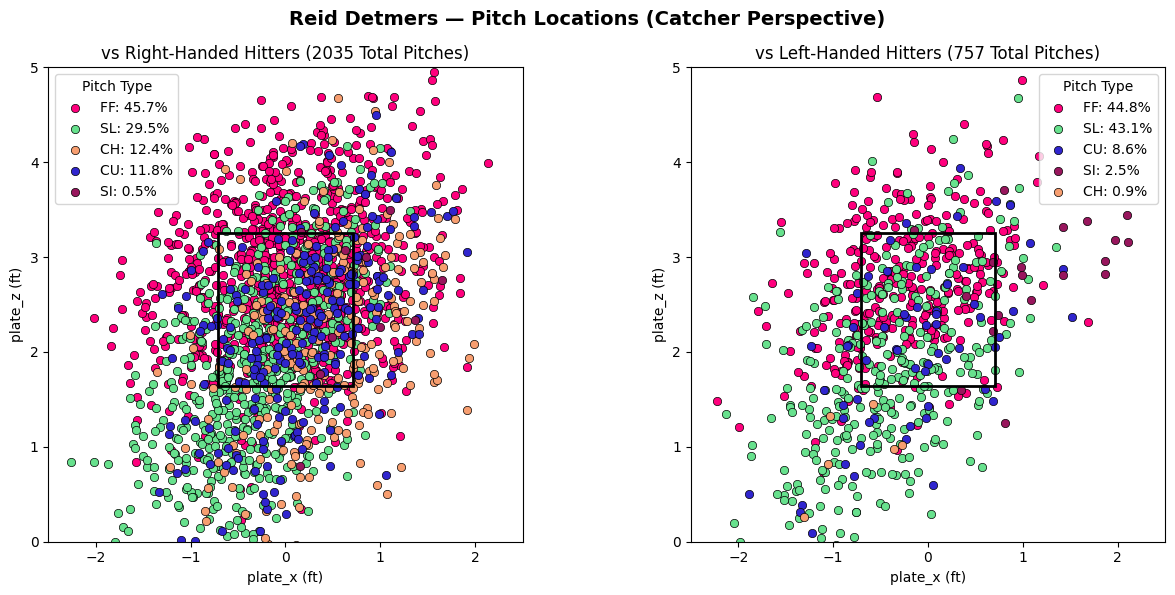

In [215]:
df_left  = pitcher_data[pitcher_data['stand'] == 'L']
df_right = pitcher_data[pitcher_data['stand'] == 'R']

fig, (ax_r, ax_l) = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle(f"{PLAYER_NAME} — Pitch Locations (Catcher Perspective)", fontsize=14, fontweight='bold')
add_pitch_strike_zone(df_right, ax_r, title=f"vs Right-Handed Hitters ({len(df_right)} Total Pitches)")
add_pitch_strike_zone(df_left,  ax_l, title=f"vs Left-Handed Hitters ({len(df_left)} Total Pitches)")
plt.tight_layout()
plt.show()

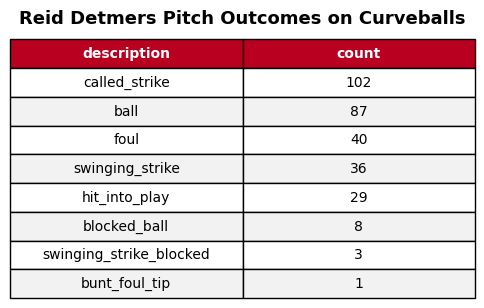

In [216]:
curveball_outcomes = (
    pitcher_curveball_data['description']
    .value_counts()
    .reset_index()
)
curveball_outcomes.columns = ['description', 'count']
plot_table(curveball_outcomes, "Reid Detmers Pitch Outcomes on Curveballs")

In [217]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

league = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'total_pitches': ct.sum(axis=1)
})
league['called_strike_rate'] = round(league['called_strike'] / league['total_pitches'] * 100, 2)
league = league[league['total_pitches'] >= 100]

pitcher_rate = league.loc[DATASET_NAME, 'called_strike_rate']
league_avg = league['called_strike_rate'].mean()
percentile = (league['called_strike_rate'] < pitcher_rate).mean() * 100

print(f"{PLAYER_NAME}: {pitcher_rate}% called strike rate")
print(f"League average: {league_avg:.2f}%")
print(f"Percentile: {percentile:.0f}th")

Reid Detmers: 33.33% called strike rate
League average: 18.62%
Percentile: 99th


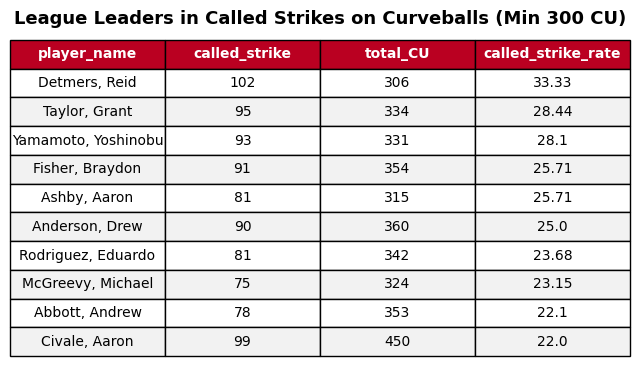

In [218]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

summary = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'total_CU': ct.sum(axis=1)
})
summary['called_strike_rate'] = round(summary['called_strike'] / summary['total_CU'] * 100, 2)
summary = summary[summary['total_CU'] >= 300]

plot_table(summary.sort_values('called_strike_rate', ascending=False).head(10).reset_index(), "League Leaders in Called Strikes on Curveballs (Min 300 CU)", figsize=(8,3))

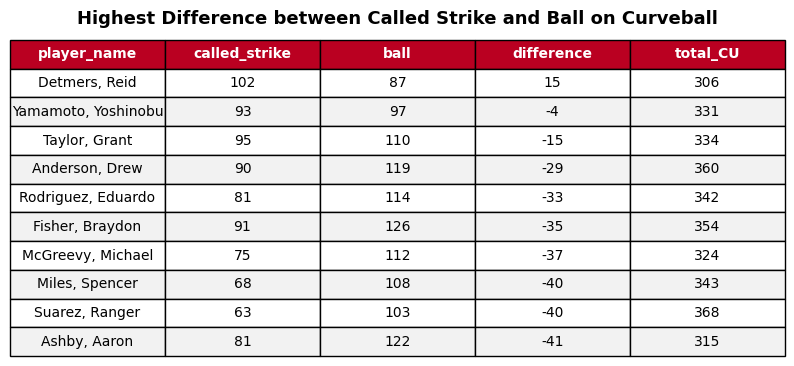

In [246]:
ct = pd.crosstab(league_curveball_data['player_name'], league_curveball_data['description'])

summary = pd.DataFrame({
    'called_strike': ct['called_strike'],
    'ball': ct['ball'],
    'difference': ct['called_strike'] - ct['ball'],
    'total_CU': ct.sum(axis=1)
}).sort_values(['difference'], ascending=False)

summary = summary[summary['total_CU'] >= 300]

plot_table(summary.head(10).reset_index(), "Highest Difference between Called Strike and Ball on Curveball", figsize=(10, 3))

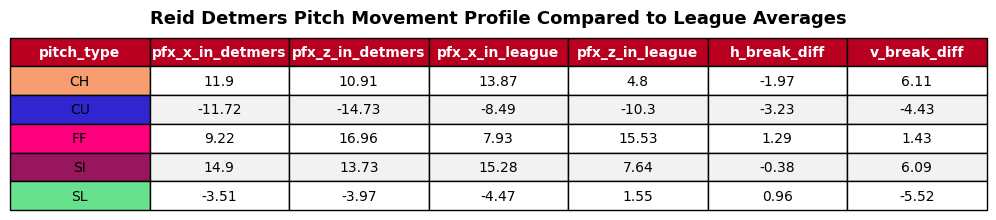

In [220]:
pitcher_movement = (
    data[data['pitcher'] == PLAYER_ID]
    .groupby('pitch_type')[['pfx_x_in', 'pfx_z_in']]
    .mean().round(2)
)

league_movement = (
    data.groupby(['pitch_type', 'p_throws'])[['pfx_x_in', 'pfx_z_in']]
    .mean().round(2)
)
comparison = pitcher_movement.merge(
    league_movement.xs('L', level='p_throws'),
    on='pitch_type',
    suffixes=('_detmers', '_league')
)

comparison['h_break_diff'] = round(comparison['pfx_x_in_detmers'] - comparison['pfx_x_in_league'], 2)
comparison['v_break_diff'] = round(comparison['pfx_z_in_detmers'] - comparison['pfx_z_in_league'], 2)
plot_table(comparison.reset_index(), "Reid Detmers Pitch Movement Profile Compared to League Averages", color_col="pitch_type")

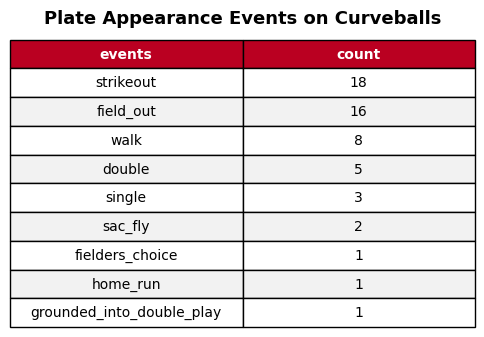

In [221]:
pitcher_curveball_events = (
    pitcher_curveball_data['events']
    .value_counts()
    .reset_index()
)
plot_table(pitcher_curveball_events, "Plate Appearance Events on Curveballs")

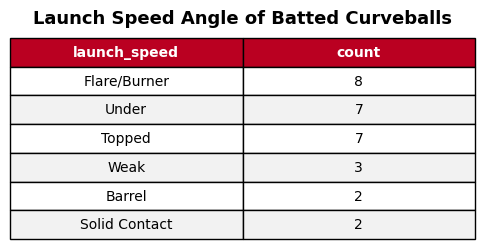

In [222]:
pitcher_curveball_lsa = (
    pitcher_curveball_data['launch_speed']
    .value_counts()
    .reset_index()
)
plot_table(pitcher_curveball_lsa, "Launch Speed Angle of Batted Curveballs")

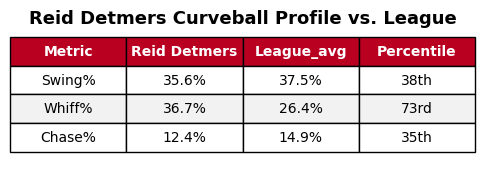

In [223]:
def generate_swing_metrics(df: pd.DataFrame):
    pitch_stats = (
        df.groupby(['player_name'])
            .agg(
                curveballs=('pitch_type', 'count'),
                swings=('swing', 'sum'),
                whiffs=('whiff', 'sum'),
                chases=('chase', 'sum'),
            )
    )
    pitch_stats['swing_pct'] = (pitch_stats['swings'] / pitch_stats['curveballs'] * 100).round(2)
    pitch_stats['whiff_pct'] = (pitch_stats['whiffs'] / pitch_stats['swings'] * 100).round(2)
    pitch_stats['chase_pct'] = (pitch_stats['chases'] / pitch_stats['curveballs'] * 100).round(2)
    pitch_stats = pitch_stats.reset_index()

    return pitch_stats

def summarize_rate(df: pd.DataFrame, league_df: pd.DataFrame, name_col: str, metric_col: str, player_name: str):
    player_rate = df.loc[df[name_col] == player_name, metric_col].iloc[0]
    league_avg = league_df[metric_col].mean()
    percentile = (league_df[metric_col] < player_rate).mean() * 100
    return player_rate, league_avg, percentile

def swing_metrics_table(pitch_stats: pd.DataFrame, league_stats: pd.DataFrame):
    def ordinal_suffix(n: int) -> str:
        if 10 <= n % 100 <= 20:
            return 'th'
        return {1: 'st', 2: 'nd', 3: 'rd'}.get(n % 10, 'th')

    metrics = ['swing_pct', 'whiff_pct', 'chase_pct']
    rows = []
    for m in metrics:
        player_rate, league_avg, percentile = summarize_rate(
            pitch_stats, league_stats, 'player_name', m, DATASET_NAME
        )
        rows.append({
            'Metric': f"{m.replace('_pct', '').title()}%",
            f'{PLAYER_NAME}': f'{player_rate:.1f}%',
            'League_avg': f'{league_avg:.1f}%',
            'Percentile': f'{percentile:.0f}{ordinal_suffix(round(percentile))}',
        })

    summary_df = pd.DataFrame(rows)
    return summary_df

curveball_swing_rates = generate_swing_metrics(pitcher_curveball_data)

league_curveball_rates = generate_swing_metrics(league_curveball_data)

summary_df = swing_metrics_table(curveball_swing_rates, league_curveball_rates)
plot_table(summary_df, f"{PLAYER_NAME} Curveball Profile vs. League", figsize=(6,1.5))

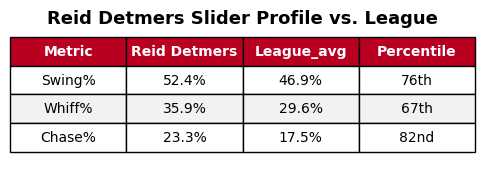

In [224]:
slider_swing_rates = generate_swing_metrics(pitcher_slider_data)

league_slider_swing_rates = generate_swing_metrics(league_slider_data)

summary_df = swing_metrics_table(slider_swing_rates, league_slider_swing_rates)
plot_table(summary_df, f"{PLAYER_NAME} Slider Profile vs. League", figsize=(6,1.5))

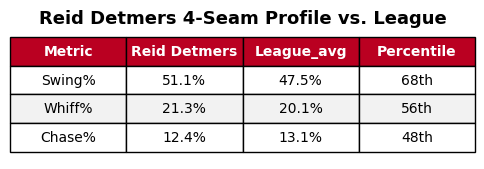

In [225]:
fastball_swing_rates = generate_swing_metrics(pitcher_fastball_data)

league_fastball_swing_rates = generate_swing_metrics(league_fastball_data)

summary_df = swing_metrics_table(fastball_swing_rates, league_fastball_swing_rates)
plot_table(summary_df, f"{PLAYER_NAME} 4-Seam Profile vs. League", figsize=(6,1.5))

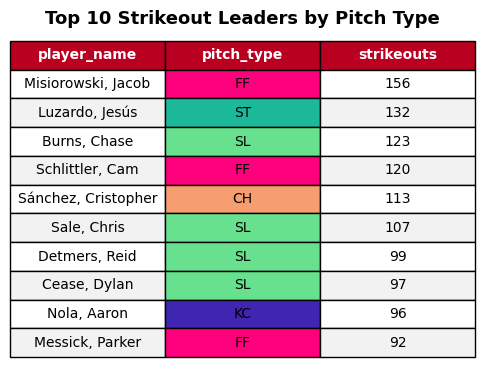

In [226]:
strikeout_events = data[data['events'].isin(['strikeout', 'strikeout_double_play'])]

strikeouts_by_pitch = (
    strikeout_events.groupby(['player_name', 'pitch_type'])
    .size()
    .reset_index(name='strikeouts')
)

top10 = strikeouts_by_pitch.sort_values('strikeouts', ascending=False).head(10)
plot_table(top10, "Top 10 Strikeout Leaders by Pitch Type", color_col="pitch_type")

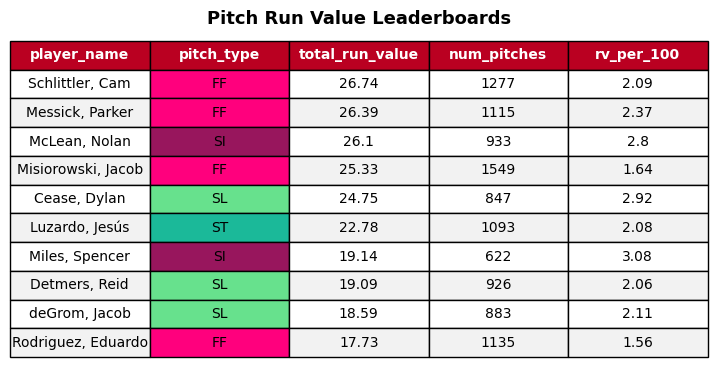

In [227]:
run_value = (
    data.groupby(['player_name', 'pitch_type'])['delta_run_exp']
    .agg(total_run_value='sum', num_pitches='count')
    .round(2)
)
run_value['total_run_value'] = run_value['total_run_value'] * -1
run_value['rv_per_100'] = (run_value['total_run_value'] / run_value['num_pitches'] * 100).round(2)
run_value = run_value.reset_index() 

plot_table(run_value.sort_values('total_run_value', ascending=False).head(10), "Pitch Run Value Leaderboards", color_col="pitch_type")

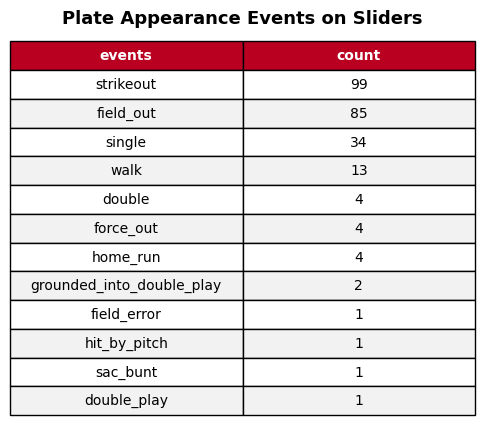

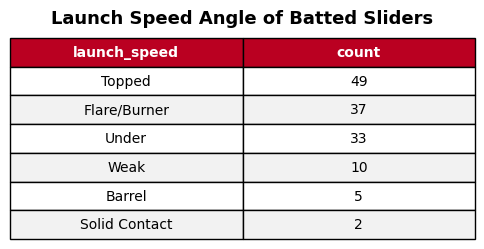

In [228]:
pitcher_slider_data['events'].value_counts()
pitcher_slider_events = (
    pitcher_slider_data['events']
    .value_counts()
    .reset_index()
)
plot_table(pitcher_slider_events, "Plate Appearance Events on Sliders")

pitcher_slider_lsa = (
    pitcher_slider_data['launch_speed']
    .value_counts()
    .reset_index()
)
plot_table(pitcher_slider_lsa, "Launch Speed Angle of Batted Sliders")

In [229]:
def plot_pitch_count_usage(df: pd.DataFrame, title: str):
    situation = (
        pd.crosstab(df['description'], df['count'])
    )
    fig, ax1 = plt.subplots(figsize=(10, 6))

    sns.heatmap(situation, annot=True, fmt='d', cmap='Reds', ax=ax1, cbar=True)
    ax1.set_title(f"Detmers {title} Pitch Results by Count",  fontweight='bold')

    plt.tight_layout()
    plt.show()

def pitch_total_by_count(df: pd.DataFrame):
    count_order = ['0-0', '0-1', '0-2', '1-0', '1-1', '1-2', '2-0', '2-1', '2-2', '3-0', '3-1', '3-2']

    pitch_by_count = (
    df['count']
        .value_counts()
        .rename_axis('count')    
        .reset_index(name='Total Pitches') 
    )
    pitch_by_count['count'] = pd.Categorical(
        pitch_by_count['count'], categories=count_order, ordered=True
    )

    pitch_by_count['Situation Rate'] = (pitch_by_count['Total Pitches'] / pitch_by_count['Total Pitches'].sum() * 100).round(2)
    
    pitch_by_count = pitch_by_count.sort_values('count').reset_index(drop=True)
    return pitch_by_count

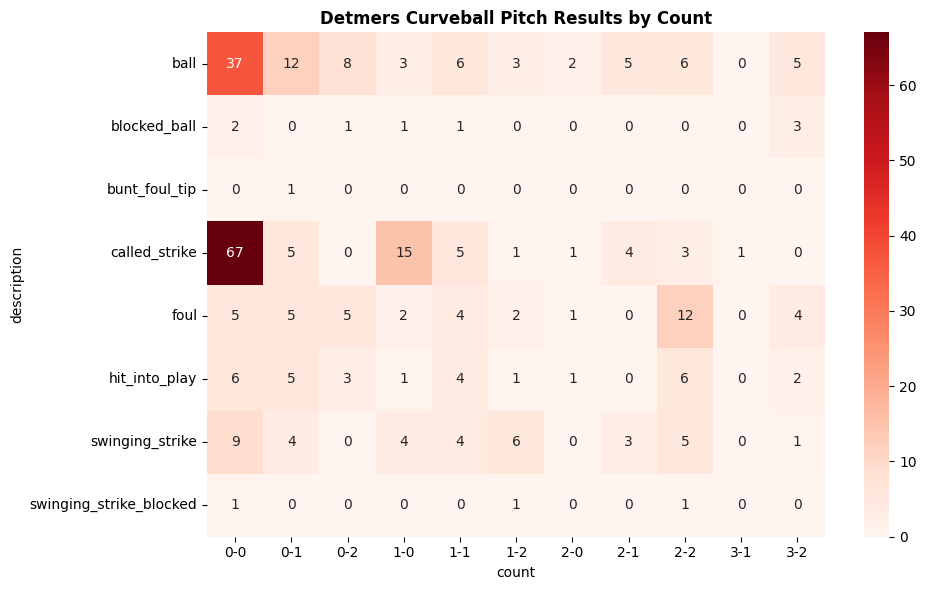

In [230]:
plot_pitch_count_usage(pitcher_curveball_data, "Curveball")

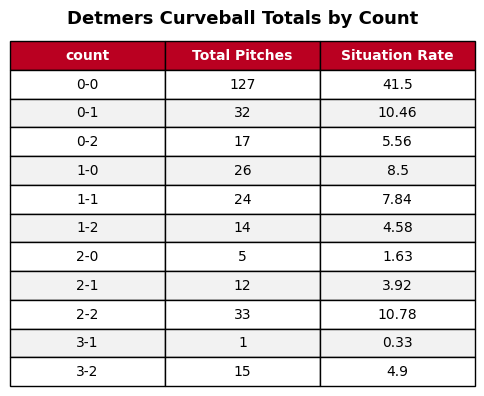

In [231]:
curveball_by_count = pitch_total_by_count(pitcher_curveball_data)
plot_table(curveball_by_count, title="Detmers Curveball Totals by Count")

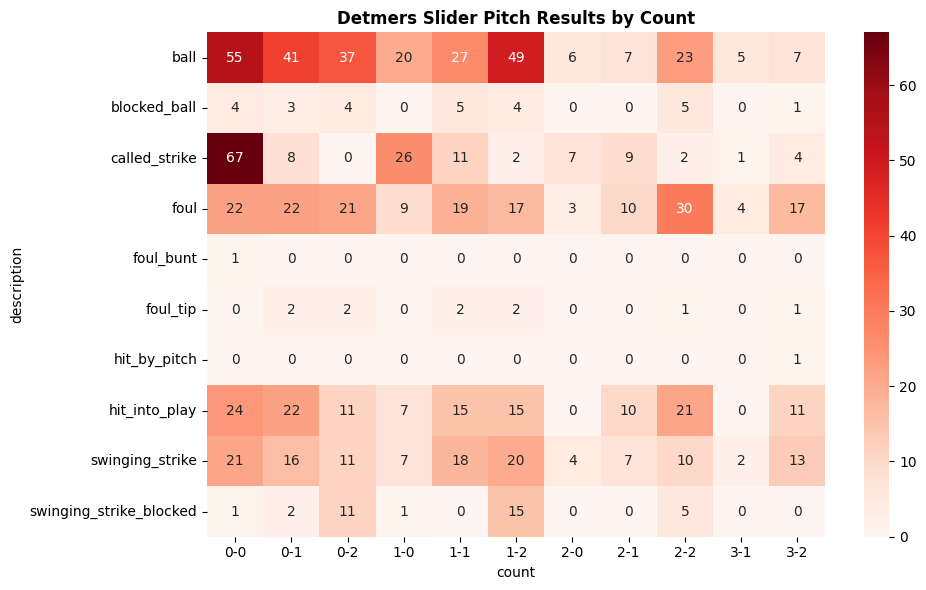

In [232]:
plot_pitch_count_usage(pitcher_slider_data, "Slider")

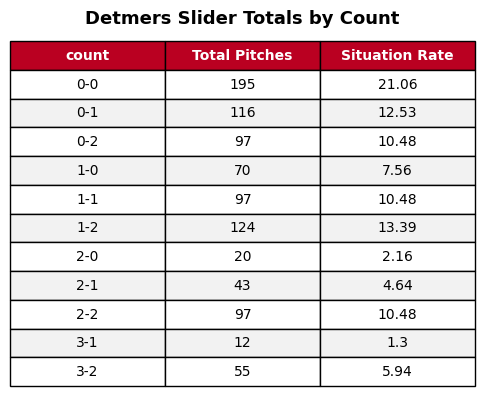

In [233]:
sliders_by_count = pitch_total_by_count(pitcher_slider_data)
plot_table(sliders_by_count, title="Detmers Slider Totals by Count")

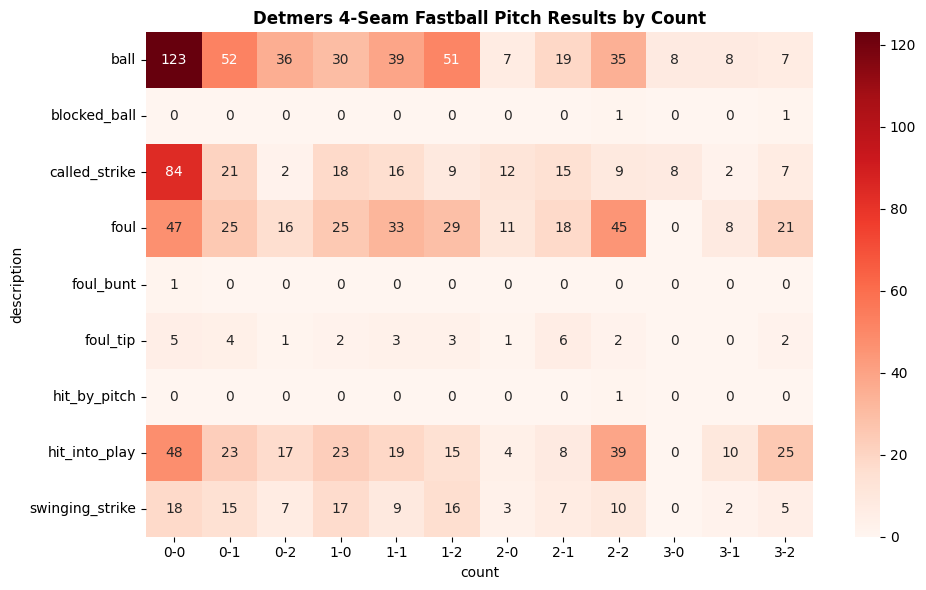

In [234]:
pitcher_four_seam_data = pitcher_data[pitcher_data['pitch_type'] == 'FF']
plot_pitch_count_usage(pitcher_four_seam_data, "4-Seam Fastball")

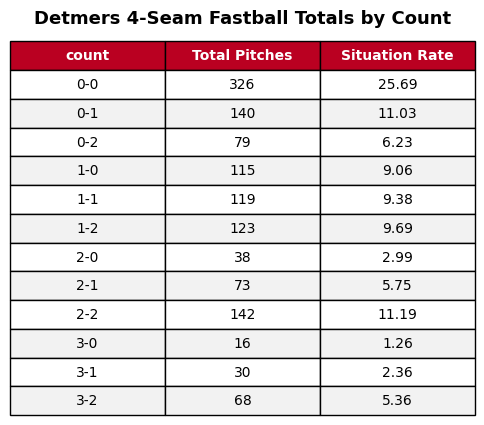

In [235]:
fastball_by_count = pitch_total_by_count(pitcher_four_seam_data)
plot_table(fastball_by_count, title="Detmers 4-Seam Fastball Totals by Count")

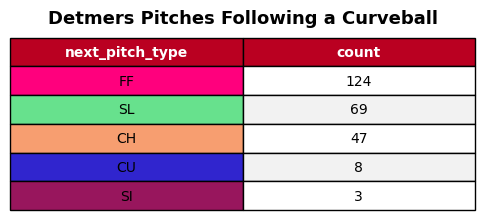

In [236]:
curveball_next_pitch = (
    pitcher_curveball_data['next_pitch_type']
    .value_counts()
    .reset_index()
)
plot_table(curveball_next_pitch, "Detmers Pitches Following a Curveball", color_col="next_pitch_type")

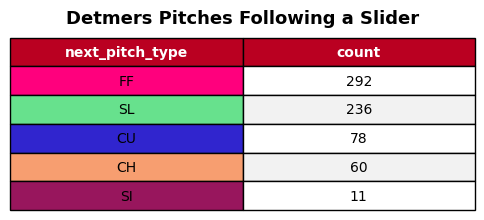

In [237]:
slider_next_pitch = (
    pitcher_slider_data['next_pitch_type']
    .value_counts()
    .reset_index()
)
plot_table(slider_next_pitch, "Detmers Pitches Following a Slider", color_col="next_pitch_type")

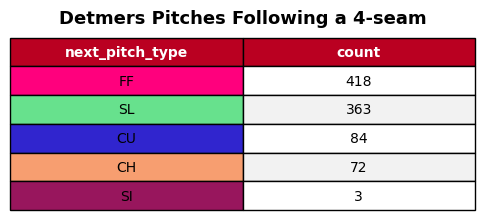

In [238]:
fastball_next_pitch = (
    pitcher_fastball_data['next_pitch_type']
    .value_counts()
    .reset_index()
)
plot_table(fastball_next_pitch, "Detmers Pitches Following a 4-seam", color_col="next_pitch_type")

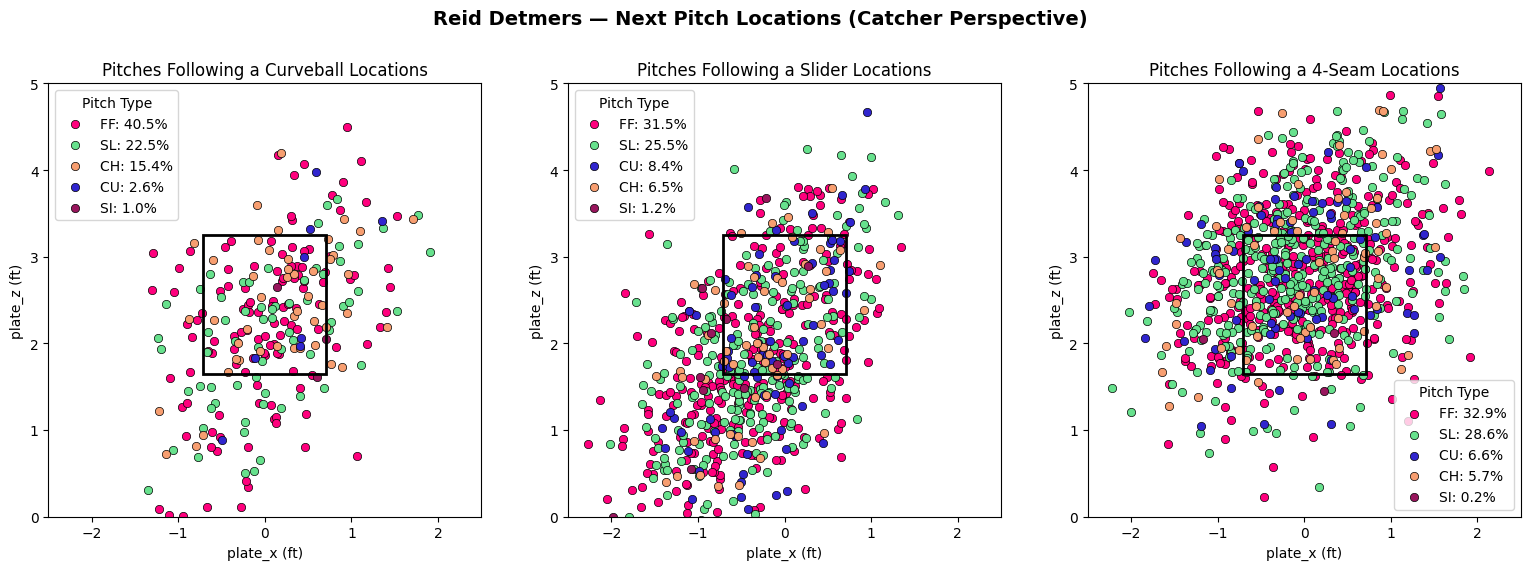

In [239]:
fastball_into_curveball = pitcher_fastball_data[(pitcher_fastball_data['next_pitch_type'] == 'CU') & (pitcher_fastball_data['pitch_type'] == 'FF')]
next_curveball = pitcher_curveball_data[['next_pitch_type', 'plate_x', 'plate_z']]
next_slider = pitcher_slider_data[['next_pitch_type', 'plate_x', 'plate_z']]
next_fastball = pitcher_fastball_data[['next_pitch_type', 'plate_x', 'plate_z']]

fig, (ax_CU, ax_SL, ax_FF) = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle(f"{PLAYER_NAME} — Next Pitch Locations (Catcher Perspective)", fontsize=14, fontweight='bold')
add_pitch_strike_zone(next_curveball, ax_CU, title=f"Pitches Following a Curveball Locations", column="next_pitch_type")
add_pitch_strike_zone(next_slider, ax_SL, title=f"Pitches Following a Slider Locations", column="next_pitch_type")
add_pitch_strike_zone(next_fastball, ax_FF, title=f"Pitches Following a 4-Seam Locations", column="next_pitch_type")